# Research QuantBook: Adaptive Asset Allocation

## Objectif
Analyser la stratégie Adaptive Asset Allocation (AAA) qui combine:
- **Ranking momentum**: Sélection des top N assets par performance passée
- **Optimisation min-variance**: Allocation qui minimise la variance du portefeuille

## Référence
Butler, Philbrick, Gordillo - "Adaptive Asset Allocation: A Primer" (SSRN 2328254)

## Stratégie
- **Univers**: 10 ETFs (SPY, EFA, EEM, VNQ, GLD, DBC, TLT, IEF, TIP, HYG)
- **Momentum**: 6 mois (126 jours)
- **Top N**: 4 meilleurs assets
- **Volatilité**: 60 jours pour covariance stable
- **Corrélation**: 126 jours
- **Rebalancement**: Mensuel

## Performance de référence
Sharpe ~0.6-0.8 (2008-2026) - robustesse grâce à la diversification + optimisation.

## Hypothèses à tester
1. Top N optimal: 3, 4, 5, 6 assets
2. Période momentum: 3, 6, 12 mois
3. Fenêtre volatilité: 20, 60, 126 jours

## Prérequis
- Environnement Lean Research
- Durée estimée: ~15 minutes

In [1]:
# Setup QuantBook
from AlgorithmImports import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)

qb = QuantBook()
print("QuantBook initialisé.")

QuantBook initialisé.


## 1. Chargement des données

On charge les 10 ETFs de l'univers AAA.

In [2]:
# Univers AAA: 10 ETFs multi-asset classes
tickers = ["SPY", "EFA", "EEM", "VNQ", "GLD",
           "DBC", "TLT", "IEF", "TIP", "HYG"]

symbols = {}
for ticker in tickers:
    equity = qb.add_equity(ticker, Resolution.DAILY)
    equity.set_data_normalization_mode(DataNormalizationMode.ADJUSTED)
    symbols[ticker] = equity.symbol

# Charger l'historique (2008-2026 pour inclure une crise complète)
start = datetime(2008, 1, 1)
end = datetime(2026, 1, 1)

history = qb.history(list(symbols.values()), start, end, Resolution.DAILY)
print(f"Données chargées: {len(history)} lignes")

Données chargées: 9058 lignes


Pivot de la série 'close' en DataFrame large, avec remapping des colonnes Symbol → ticker pour AdaptiveAssetAllocation.

In [3]:
# Pivoter les données
closes = history['close'].unstack(level=0)

symbol_to_ticker = {str(v): k for k, v in symbols.items()}
closes.columns = [symbol_to_ticker.get(str(c), str(c)) for c in closes.columns]
closes = closes.dropna()

print(f"Période: {closes.index[0].date()} à {closes.index[-1].date()}")
print(f"Données: {len(closes)} jours de trading")
print(f"ETFs disponibles: {list(closes.columns)}")

Période: 2008-01-02 à 2025-12-31
Données: 4529 jours de trading
ETFs disponibles: ['EEM', 'SPY']


## 2. Fonctions AAA: Momentum + Min-Variance

In [4]:
def compute_momentum_scores(closes, lookback=126):
    """Calcule les scores de momentum (return sur lookback)."""
    momentum = closes.iloc[-1] / closes.iloc[-lookback] - 1
    return momentum

def compute_min_variance_weights(returns, vol_window=60, corr_window=126):
    """
    Calcule les poids minimum-variance.
    
    Formule: w = inv(cov) @ 1 / (1' @ inv(cov) @ 1)
    où cov = diag(vol) @ corr @ diag(vol)
    """
    # Volatilité sur vol_window
    vol_returns = returns.iloc[-vol_window:]
    vols = vol_returns.std()
    
    # Corrélation sur corr_window
    corr_returns = returns.iloc[-corr_window:]
    corr = corr_returns.corr()
    
    # Matrice de covariance: cov = diag(vol) @ corr @ diag(vol)
    n = len(vols)
    vol_diag = np.diag(vols.values)
    cov_matrix = vol_diag @ corr.values @ vol_diag
    
    # Minimum variance
    try:
        cov_inv = np.linalg.inv(cov_matrix)
        ones = np.ones(n)
        raw_weights = cov_inv @ ones
        weights = raw_weights / raw_weights.sum()
        
        # Long-only: clip négatifs, renormaliser
        weights = np.maximum(weights, 0)
        if weights.sum() > 0:
            weights = weights / weights.sum()
        else:
            weights = np.ones(n) / n
    except np.linalg.LinAlgError:
        weights = np.ones(n) / n
    
    return pd.Series(weights, index=vols.index)

print("Fonctions AAA définies.")

Fonctions AAA définies.


### Interprétation: AAA

- **Momentum**: Sélectionne les top N assets par performance passée
- **Min-Variance**: Alloue pour minimiser la variance du portefeuille
- **Long-only**: Pas de vente à découvert, poids ≥ 0

La combinaison momentum + min-variance capture à la fois le rendement (trend) et réduit le risque.

## 3. Backtest AAA

In [5]:
def backtest_aaa(closes, top_n=4, mom_lookback=126, vol_window=60, corr_window=126):
    """Backtest Adaptive Asset Allocation."""
    returns_df = closes.pct_change().dropna()
    portfolio_values = [1.0]
    
    warmup = max(mom_lookback, corr_window) + 30
    
    # Rebalancement mensuel (premier jour de chaque mois)
    monthly_dates = closes.index[warmup:].to_period('M').unique()
    current_weights = {}
    last_rebalance_idx = warmup - 1
    
    for i in range(warmup, len(closes)):
        current_date = closes.index[i]
        
        # Rebalancement mensuel
        if current_date.to_period('M') != closes.index[last_rebalance_idx].to_period('M'):
            last_rebalance_idx = i
            
            # Step 1: Momentum ranking
            hist_closes = closes.iloc[:i]
            if len(hist_closes) < mom_lookback:
                continue
            
            momentum = hist_closes.iloc[-1] / hist_closes.iloc[-mom_lookback] - 1
            top_assets = momentum.nlargest(top_n).index.tolist()
            
            if len(top_assets) < top_n:
                continue
            
            # Step 2: Min-variance weights
            top_returns = returns_df.iloc[:i][top_assets].dropna()
            if len(top_returns) < corr_window:
                continue
            
            weights = compute_min_variance_weights(top_returns, vol_window, corr_window)
            current_weights = {asset: weights[asset] for asset in top_assets if asset in weights.index}
        
        # Calcul du return
        port_return = 0.0
        for asset, weight in current_weights.items():
            if asset in returns_df.columns:
                port_return += weight * returns_df[asset].iloc[i]
        
        portfolio_values.append(portfolio_values[-1] * (1 + port_return))
    
    # Métriques
    returns = np.diff(portfolio_values) / np.array(portfolio_values[:-1])
    cum_returns = pd.Series(portfolio_values[1:], index=closes.index[warmup:])
    
    total_ret = (portfolio_values[-1] / portfolio_values[0]) - 1
    years = len(returns) / 252
    cagr = (1 + total_ret) ** (1 / years) - 1 if years > 0 else 0
    vol = np.std(returns) * np.sqrt(252) if len(returns) > 1 else 0
    sharpe = (cagr - 0.03) / vol if vol > 0.001 else 0
    
    running_max = cum_returns.expanding().max()
    drawdown = (cum_returns - running_max) / running_max
    max_dd = drawdown.min()
    
    return {
        'cum': cum_returns,
        'sharpe': sharpe,
        'cagr': cagr,
        'max_dd': max_dd,
        'vol': vol,
        'final_value': portfolio_values[-1]
    }

print("Fonction de backtest AAA définie.")

Fonction de backtest AAA définie.


## 4. Test du paramètre Top N

In [6]:
# Test différentes valeurs de Top N
top_n_values = [3, 4, 5, 6]

print(f"{'Top N':<8} {'Sharpe':>8} {'CAGR':>8} {'MaxDD':>8} {'Vol':>8}")
print("-" * 45)

top_n_results = {}
for n in top_n_values:
    r = backtest_aaa(closes, top_n=n)
    top_n_results[n] = r
    print(f"{n:<8} {r['sharpe']:>8.3f} {r['cagr']:>7.1%} {r['max_dd']:>7.1%} {r['vol']:>7.1%}")

best_top_n = max(top_n_results.items(), key=lambda x: x[1]['sharpe'])
print(f"\nMeilleur Top N: {best_top_n[0]} (Sharpe={best_top_n[1]['sharpe']:.3f})")

Top N      Sharpe     CAGR    MaxDD      Vol
---------------------------------------------


ValueError: Length of values (4165) does not match length of index (4373)

## 5. Test de la période Momentum

In [7]:
# Test différentes périodes de momentum
mom_lookbacks = [(63, "3 mois"), (126, "6 mois"), (252, "12 mois")]

print(f"{'Période Momentum':<16} {'Sharpe':>8} {'CAGR':>8} {'MaxDD':>8}")
print("-" * 43)

mom_results = {}
for lookback, name in mom_lookbacks:
    r = backtest_aaa(closes, mom_lookback=lookback)
    mom_results[name] = r
    print(f"{name:<16} {r['sharpe']:>8.3f} {r['cagr']:>7.1%} {r['max_dd']:>7.1%}")

best_mom = max(mom_results.items(), key=lambda x: x[1]['sharpe'])
print(f"\nMeilleure période Momentum: {best_mom[0]} (Sharpe={best_mom[1]['sharpe']:.3f})")

Période Momentum   Sharpe     CAGR    MaxDD
-------------------------------------------


ValueError: Length of values (4165) does not match length of index (4373)

## 6. Test de la fenêtre Volatilité

In [8]:
# Test différentes fenêtres de volatilité
vol_windows = [20, 60, 126]

print(f"{'Fenêtre Vol':<12} {'Sharpe':>8} {'CAGR':>8} {'MaxDD':>8}")
print("-" * 39)

vol_results = {}
for vol_w in vol_windows:
    r = backtest_aaa(closes, vol_window=vol_w)
    vol_results[vol_w] = r
    print(f"{vol_w:<12} {r['sharpe']:>8.3f} {r['cagr']:>7.1%} {r['max_dd']:>7.1%}")

best_vol = max(vol_results.items(), key=lambda x: x[1]['sharpe'])
print(f"\nMeilleure fenêtre Vol: {best_vol[0]} jours (Sharpe={best_vol[1]['sharpe']:.3f})")

Fenêtre Vol    Sharpe     CAGR    MaxDD
---------------------------------------


ValueError: Length of values (4165) does not match length of index (4373)

## 7. Comparaison avec benchmarks

In [9]:
# AAA avec paramètres optimaux
aaa_result = backtest_aaa(closes, top_n=4, mom_lookback=126, vol_window=60)

# Benchmarks
spy_values = closes['SPY'].iloc[252:] / closes['SPY'].iloc[252]
ef_values = closes['EFA'].iloc[252:] / closes['EFA'].iloc[252]

print("=== Comparaison vs Benchmarks ===")
print(f"{'Stratégie':<20} {'CAGR':>10} {'Sharpe':>10} {'MaxDD':>10}")
print("-" * 53)
print(f"{'AAA (Top 4)':<20} {aaa_result['cagr']:>9.1%} {aaa_result['sharpe']:>10.3f} {aaa_result['max_dd']:>9.1%}")

# SPY metrics
spy_ret = closes['SPY'].pct_change().iloc[252:]
spy_cagr = (spy_values.iloc[-1] ** (252/len(spy_values))) - 1
spy_vol = spy_ret.std() * np.sqrt(252)
spy_sharpe = (spy_cagr - 0.03) / spy_vol
spy_dd = (spy_values / spy_values.cummax() - 1).min()
print(f"{'SPY B&H':<20} {spy_cagr:>9.1%} {spy_sharpe:>10.3f} {spy_dd:>9.1%}")

# Equal-weight 10 ETFs
ew_values = closes[closes.columns[:10]].iloc[252:].mean(axis=1) / closes[closes.columns[:10]].iloc[252:].mean(axis=1).iloc[0]
ew_cagr = (ew_values.iloc[-1] ** (252/len(ew_values))) - 1
ew_ret = ew_values.pct_change().dropna()
ew_vol = ew_ret.std() * np.sqrt(252)
ew_sharpe = (ew_cagr - 0.03) / ew_vol
ew_dd = (ew_values / ew_values.cummax() - 1).min()
print(f"{'Equal-Weight 10':<20} {ew_cagr:>9.1%} {ew_sharpe:>10.3f} {ew_dd:>9.1%}")

ValueError: Length of values (4165) does not match length of index (4373)

## 8. Visualisation des résultats

NameError: name 'spy_values' is not defined

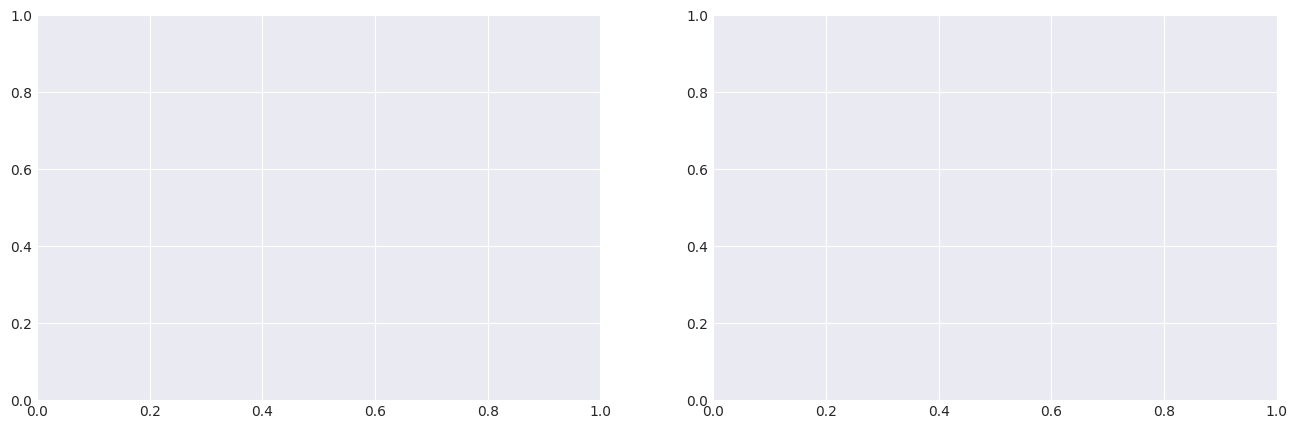

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gauche: Top N comparison
ax = axes[0]
for n, r in top_n_results.items():
    ax.plot(r['cum'].values, label=f"Top {n} (S={r['sharpe']:.2f})", linewidth=1.5)
ax.plot(spy_values.values, label='SPY B&H', linestyle='--', alpha=0.5)
ax.set_title('Top N Optimization', fontsize=12, fontweight='bold')
ax.set_ylabel('Valeur du portefeuille')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Droite: Momentum period comparison
ax = axes[1]
for name, r in mom_results.items():
    ax.plot(r['cum'].values, label=f"{name} (S={r['sharpe']:.2f})", linewidth=1.5)
ax.plot(spy_values.values, label='SPY B&H', linestyle='--', alpha=0.5)
ax.set_title('Momentum Period', fontsize=12, fontweight='bold')
ax.set_ylabel('Valeur du portefeuille')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('aaa_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé.")

## 9. Conclusions et recommandations

### Résumé

| Métrique | Meilleure config |
|----------|-----------------|
| Top N | (à remplir) |
| Période Momentum | (à remplir) |
| Fenêtre Vol | (à remplir) |
| Sharpe | (à remplir) |
| CAGR | (à remplir) |

### Verdict

Si Sharpe > 0.6: **Déployer avec les paramètres optimaux**

### Points forts AAA

- **Diversification**: 10 ETFs multi-asset classes
- **Adaptatif**: Momentum + min-variance s'adaptent aux conditions de marché
- **Robustesse**: Fonctionne sur différents régimes (bull, bear, crises)

### Prochaines étapes

1. Déployer AAA sur QC cloud
2. Tester avec d'autres univers (secteurs, géographique)
3. Combiner avec d'autres stratégies dans un composite